In [4]:
import pandas as pd
import sys
import os

sys.path.append("../../..")
from typing import Optional, Union
import yaml

import src.chunkbench.path_utils as pu

pd.set_option("display.max_columns", None)


def process_one(run_id: Union[str, int]) -> Optional[pd.DataFrame]:
    run_params_path = os.path.join(pu.DATA_PATH, "runs", str(run_id), "run_params.yml")
    sys_query_history_path = os.path.join(
        pu.DATA_PATH, "runs", str(run_id), "sys_query_history.parquet"
    )
    conn_info_path = os.path.join(pu.CHUNKBENCH_ROOT, "config", "conn.yml")

    # Check file existence and read them in.
    if (
        not os.path.exists(run_params_path)
        or not os.path.exists(sys_query_history_path)
        or not os.path.exists(conn_info_path)
    ):
        print(f"Missing files for run_id {run_id}")
        return None
    with open(run_params_path, "r") as f:
        run_params = yaml.safe_load(f)
    with open(conn_info_path, "r") as f:
        conn_info = yaml.safe_load(f)
    endpoint_name = run_params["endpoint_name"]
    if endpoint_name not in conn_info["endpoints"]:
        print(f"Endpoint {endpoint_name} not found in connection info.")
        return None
    endpoint_rpu = conn_info["endpoints"][endpoint_name]["rpu"]
    sys_query_history = pd.read_parquet(sys_query_history_path)

    # Process columns as needed.
    assert all(
        sys_query_history["result_cache_hit"] == False
    ), "Expected all cache misses"
    sys_query_history["full_internal_query_id"] = sys_query_history["query_text"].apply(
        lambda x: x.split("\\n")[0][3:]
    )
    sys_query_history[
        ["run_id", "run_query_count", "tpcds_template_id", "tpcds_query_in_template"]
    ] = sys_query_history["full_internal_query_id"].str.split("/", expand=True)
    sys_query_history["run_id"] = sys_query_history["run_id"].astype(int)
    sys_query_history["run_query_count"] = sys_query_history["run_query_count"].astype(
        int
    )
    sys_query_history["tpcds_template_id"] = sys_query_history[
        "tpcds_template_id"
    ].astype(int)
    sys_query_history["tpcds_query_in_template"] = sys_query_history[
        "tpcds_query_in_template"
    ].astype(int)
    sys_query_history["endpoint_name"] = endpoint_name
    sys_query_history["endpoint_rpu"] = endpoint_rpu

    # Convert all the columns ending in "_time" from microseconds to seconds and append "_s" to their names.
    US_IN_S = 1_000_000
    time_columns = [
        col
        for col in sys_query_history.columns
        if col.endswith("_time") and col not in ["start_time", "end_time"]
    ]
    for col in time_columns:
        sys_query_history[col] = sys_query_history[col] / US_IN_S
        sys_query_history.rename(columns={col: f"{col}_s"}, inplace=True)

    # Filter/order useful columns
    column_list = [
        "run_id",
        "run_query_count",
        "tpcds_template_id",
        "tpcds_query_in_template",
        "endpoint_name",
        "endpoint_rpu",
        "start_time",
        "end_time",
        "elapsed_time_s",
        "queue_time_s",
        "execution_time_s",
        "compile_time_s",
        "planning_time_s",
        "lock_wait_time_s",
    ]
    filtered = sys_query_history[column_list]

    return filtered

def process_all() -> pd.DataFrame:
    all_dfs = []
    runs_dir = os.path.join(pu.DATA_PATH, "runs")
    for run_id in os.listdir(runs_dir):
        df = process_one(run_id)
        if df is not None:
            all_dfs.append(df)
    if all_dfs:
        return pd.concat(all_dfs, ignore_index=True)
    else:
        return pd.DataFrame()


df = process_all()
df

,run_id,run_query_count,tpcds_template_id,tpcds_query_in_template,endpoint_name,endpoint_rpu,start_time,end_time,elapsed_time_s,queue_time_s,execution_time_s,compile_time_s,planning_time_s,lock_wait_time_s
0,759156817,0,86,3,128,128,2025-09-29 14:40:17.363201,2025-09-29 14:40:19.821526,2.458325,0.0,1.080755,0.213303,1.220322,0.000104
1,759156817,1,82,1,128,128,2025-09-29 14:40:19.839418,2025-09-29 14:40:21.925806,2.086388,0.0,1.743519,0.153633,0.221528,0.000116
2,759156817,2,99,1,128,128,2025-09-29 14:40:21.950099,2025-09-29 14:40:23.798165,1.848066,0.0,1.464524,0.200802,0.281802,0.000117
3,759156817,3,20,2,128,128,2025-09-29 14:40:23.815990,2025-09-29 14:40:24.242838,0.426848,0.0,0.256156,0.120345,0.048306,0.000045
4,759156817,4,88,1,128,128,2025-09-29 14:40:24.268421,2025-09-29 14:40:28.447705,4.179284,0.0,3.683969,0.266503,0.240396,0.000188
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4450,759156803,886,32,1,32,32,2025-09-29 15:40:44.130953,2025-09-29 15:40:44.284847,0.153894,0.0,0.060238,0.000441,0.071118,0.000032
4451,759156803,887,85,2,32,32,2025-09-29 15:40:44.301738,2025-09-29 15:40:44.918754,0.617016,0.0,0.491094,0.000599,0.090327,0.000039
4452,759156803,888,3,3,32,32,2025-09-29 15:40:44.936235,2025-09-29 15:40:45.549678,0.613443,0.0,0.558151,0.000240,0.039599,0.000023
4453,759156803,889,13,3,32,32,2025-09-29 15:40:45.567039,2025-09-29 15:40:46.237761,0.670722,0.0,0.573324,0.000439,0.070093,0.000030


In [6]:
# Calculate the coefficient of variation in elapsed time, grouping per endpoint and query template.
cv_df = (
    df.groupby(["endpoint_name", "tpcds_template_id"])
    .agg(
        count=("elapsed_time_s", "count"),
        mean_elapsed_time=("elapsed_time_s", "mean"),
        std_elapsed_time=("elapsed_time_s", "std"),
    )
    .reset_index()
)
cv_df["cv_elapsed_time_s"] = cv_df["std_elapsed_time"] / cv_df["mean_elapsed_time"]
cv_df = cv_df.sort_values(by="cv_elapsed_time_s", ascending=False)
cv_df

,endpoint_name,tpcds_template_id,count,mean_elapsed_time,std_elapsed_time,cv_elapsed_time_s
283,256,86,9,0.639457,1.409639,2.204431
344,32,48,9,1.981107,3.979625,2.008788
245,256,48,9,0.627933,1.197832,1.907579
47,128,48,9,0.711471,1.345874,1.891678
40,128,41,9,0.744807,1.349696,1.812140
...,...,...,...,...,...,...
293,256,96,9,0.210009,0.002799,0.013330
383,32,87,9,6.086752,0.079388,0.013043
300,32,4,9,19.819155,0.242856,0.012254
95,128,96,9,0.312049,0.002543,0.008150


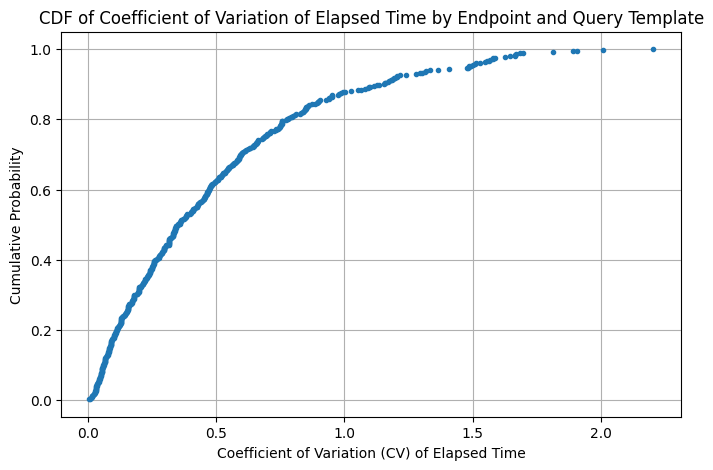

In [7]:
# Plot the cdf of cvs
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(8, 5))
sorted_cvs = np.sort(cv_df["cv_elapsed_time_s"].dropna())
cdf = np.arange(1, len(sorted_cvs) + 1) / len(sorted_cvs)
plt.plot(sorted_cvs, cdf, marker='.', linestyle='none')
plt.xlabel('Coefficient of Variation (CV) of Elapsed Time')
plt.ylabel('Cumulative Probability')
plt.title('CDF of Coefficient of Variation of Elapsed Time by Endpoint and Query Template')
plt.grid(True)
plt.show()

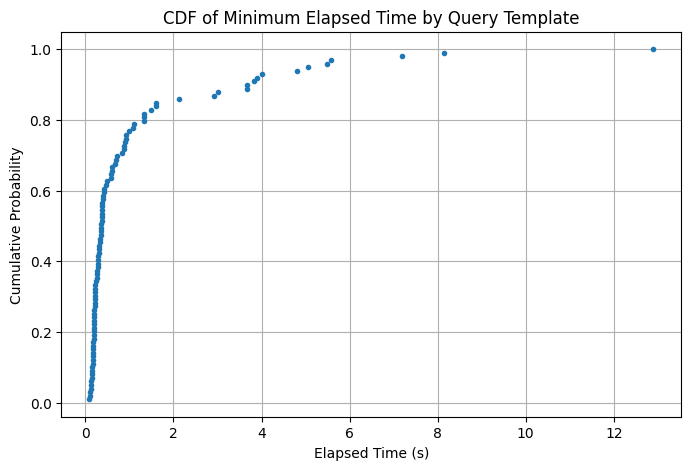

In [44]:
# Plot a cdf that says the following: For a value of time x, what percentage of query templates are always slower than x in every execution we saw?
import matplotlib.pyplot as plt
import numpy as np

# For each query template, get the min elapsed time across all endpoints and runs.
min_times = df.groupby('tpcds_template_id')['elapsed_time_s'].min().reset_index()

plt.figure(figsize=(8, 5))
sorted_min_times = np.sort(min_times['elapsed_time_s'])
cdf = np.arange(1, len(sorted_min_times) + 1) / len(sorted_min_times)
plt.plot(sorted_min_times, cdf, marker='.', linestyle='none')
plt.xlabel('Elapsed Time (s)')
plt.ylabel('Cumulative Probability')
plt.title('CDF of Minimum Elapsed Time by Query Template')
plt.grid(True)
plt.show()

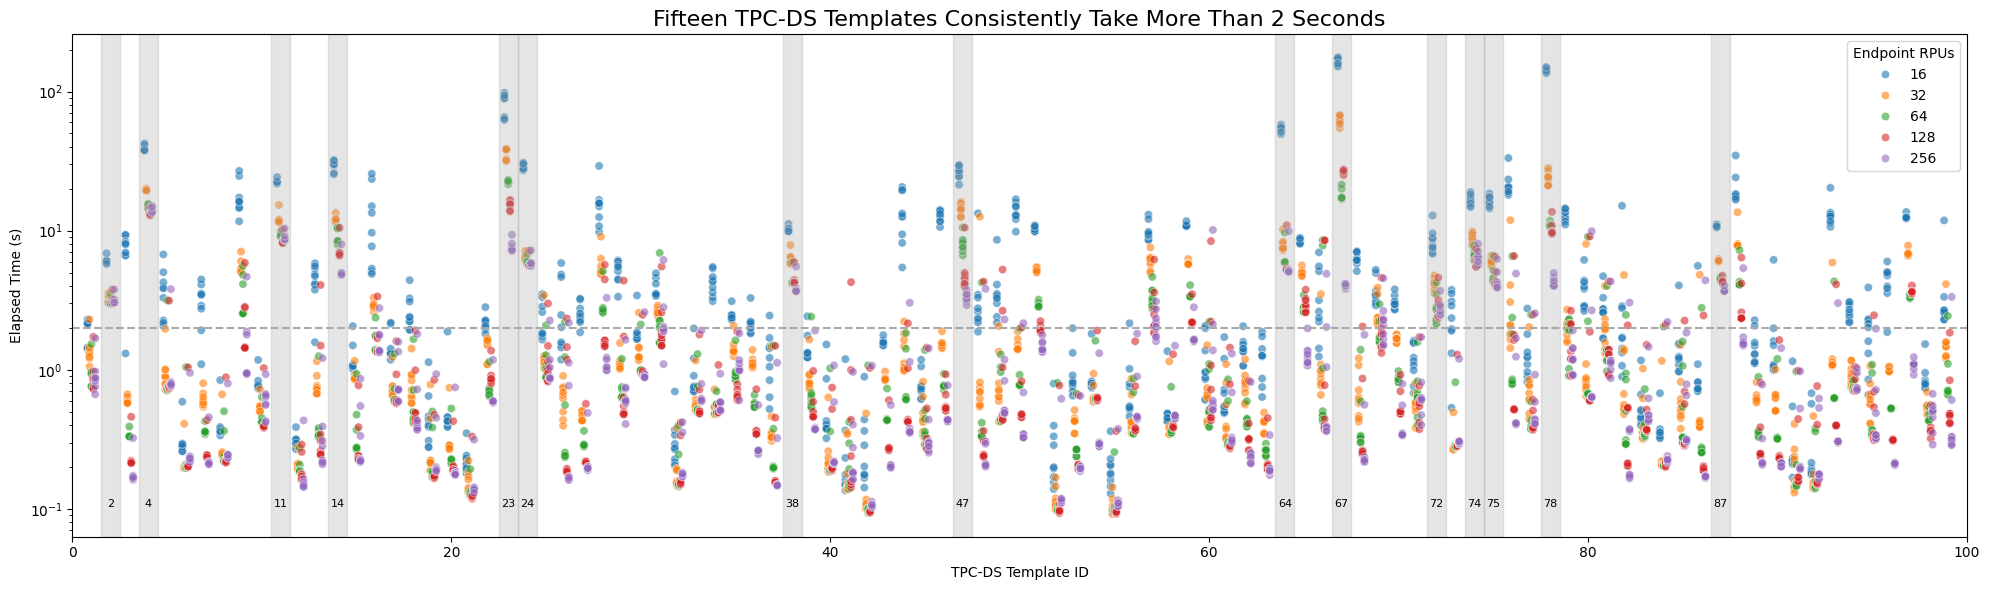

In [45]:
# Plot a grouped scatter plot, where the y axis is elapsed time in log scale. The x axis is the query template id. For each x axis value, there is a point for the mean of each endpoint, with different colors.
# Cast the endpoint names as integers and set the palette accordingly to get darker colors for higher rpu values.
import seaborn as sns
fig, ax = plt.subplots(figsize=(20, 6))

possible_rpus = sorted(df['endpoint_rpu'].unique())
rpu_to_int = {rpu: i for i, rpu in enumerate(possible_rpus)}


df['xpos'] = df['tpcds_template_id'] + df['endpoint_rpu'].map(rpu_to_int) * 0.1 - (len(possible_rpus) - 1) * 0.1 / 2


# Make sure to pick a palette with distinctive enough colors.
sns.scatterplot(
    data=df.sort_values(by="endpoint_rpu"),
    x="xpos",
    y="elapsed_time_s",
    hue="endpoint_name",
    alpha=0.6,
    ax=ax,

)

# Draw a horizontal line at 2 seconds
ax.axhline(2, color='darkgray', linestyle='--')

# For each template where all executions are above 2 seconds, shade its area in light red. Also write the template id at the bottom of the shaded area/
templates_above_2s = df.groupby('tpcds_template_id').filter(lambda x: (x['elapsed_time_s'] > 2).all())['tpcds_template_id'].unique()
for template_id in templates_above_2s:
    ax.axvspan(template_id - 0.5, template_id + 0.5, color='darkgray', alpha=0.3)
    ax.text(template_id, 0.1, str(template_id), color='black', ha='center', va='bottom', fontsize=8)

ax.set_yscale("log")
ax.set_xlim(df['tpcds_template_id'].min() - 1, df['tpcds_template_id'].max() + 1)
ax.set_ylabel("Elapsed Time (s)")
ax.set_xlabel("TPC-DS Template ID")
ax.set_title("Fifteen TPC-DS Templates Consistently Take More Than 2 Seconds", fontsize=16)
ax.legend(title="Endpoint RPUs", loc='upper right')
plt.tight_layout()
plt.savefig("heavy_hitters_scatter.png", dpi=300)
plt.show()

In [ ]:
# Save out the processed dataframe for future use.
df['heavy_hitter'] = df['tpcds_template_id'].isin(templates_above_2s)
df.to_parquet(os.path.join(pu.DATA_PATH, "query_history_processed.parquet"))

with open(os.path.join(pu.DATA_PATH, "heavy_hitter_templates.txt"), "w") as f:
    for template_id in sorted(templates_above_2s):
        f.write(f"{template_id}\n")